In [1]:
from pathlib import Path
import json
import os
from urllib.error import HTTPError, URLError
from urllib.parse import urlencode
from urllib.request import urlopen

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

current_path = Path.cwd()
project_root = current_path if (current_path / "notebooks").exists() else current_path.parent

notebooks_dir = project_root / "notebooks"
data_dir = project_root / "data"
env_path = project_root / ".env"
gitignore_path = project_root / ".gitignore"
previous_notebook_path = notebooks_dir / "05_api_json_fred_intro.ipynb"
output_csv_path = data_dir / "unrate.csv"

print("pandas_version:", pd.__version__)
print("project_root:", project_root)
print("noteooks_dir_exists:", notebooks_dir.exists())
print("data_dir_exists:", data_dir.exists())
print("previous_notebook_exists:", previous_notebook_path.exists())
print("env_file_exists:", env_path.exists())
print("gitignore_exists:", gitignore_path.exists())
print("output_csv_path:", output_csv_path)

pandas_version: 2.0.3
project_root: /Users/im-youngchan/Desktop/US Financial
noteooks_dir_exists: True
data_dir_exists: True
previous_notebook_exists: True
env_file_exists: True
gitignore_exists: True
output_csv_path: /Users/im-youngchan/Desktop/US Financial/data/unrate.csv


In [2]:
load_dotenv(dotenv_path=env_path, override=False)
fred_api_key = os.getenv("FRED_API_KEY")

invalid_key_values = {
    None,
    "",
    "replace_with_your_fred_api_key",
}

if fred_api_key in invalid_key_values:
    raise ValueError(
        "FRED_API_KEY가 준비되지 않아습니다. "
        "프로젝트 루트의 .env에 실제 key를 저장한 뒤 다시 실행하세요."
    )

print("fred_api_key_loaded:", True)

fred_api_key_loaded: True


In [3]:
fred_endpoint = "https://api.stlouisfed.org/fred/series/observations"
series_id = "UNRATE"
observation_start = "2019-01-01"
observation_end = "2024-12-31"
sort_order = "asc"

request_params = {
    "series_id": series_id,
    "api_key": fred_api_key,
    "file_type": "json", 
    "observation_start": observation_start, 
    "observatopn_end": observation_end, 
    "sort_order": sort_order,
}

safe_request_params = {
    **request_params,
    "api_key": "***",
}

safe_request_text = json.dumps(safe_request_params, sort_keys=True)

print("fred_endpoint:", fred_endpoint)
print("safe_request_params:", safe_request_params)
print("safe_request_has_mask:", '"api_key": ***' in safe_request_text)
print("actual_key_hidden_in_preview:", fred_api_key not in safe_request_text)

fred_endpoint: https://api.stlouisfed.org/fred/series/observations
safe_request_params: {'series_id': 'UNRATE', 'api_key': '***', 'file_type': 'json', 'observation_start': '2019-01-01', 'observatopn_end': '2024-12-31', 'sort_order': 'asc'}
safe_request_has_mask: False
actual_key_hidden_in_preview: True


In [4]:
request_query = urlencode(request_params)
request_url_with_key = f"{fred_endpoint}?{request_query}"

try:
    with urlopen(request_url_with_key, timeout=30) as response:
        response_status = response.status
        response_content_type = response.headers.get_content_type()
        response_text = response.read().decode("utf-8")
except HTTPError as error:
    raise RuntimeError(
        f"FRED API reques가 HTTP 상태 {error.code}로 실패했습니다."
    ) from error
except URLError as error:
    raise RuntimeError(
        f"FRED API 연결에 실패했습니다: {error.reason}"
    )from error

print("response_status:", response_status)
print("response_content_type:", response_content_type)
print("response_text_length", len(response_text))

response_status: 200
response_content_type: application/json
response_text_length 8737


In [5]:
fred_response_json = json.loads(response_text)
observations = fred_response_json.get("observations", [])

if not observations:
    raise ValueError(
        "observations 목록이 비어 있습니다. "
        "series_id, 날짜 범위, API key를 확인하세요."
    )

required_observation_keys = {"date", "value"}
all_observations_ready = all(
    required_observation_keys.issubset(observation)
    for observation in observations
)

print("response_python_type:", type(fred_response_json).__name__)
print("response_top_level_keys:", list(fred_response_json.keys()))
print("response_count:", fred_response_json.get("count"))
print("returned_observation_count:", len(observations))
print("all_observations_ready:", all_observations_ready)
print("first_observation:", observations[0])
print("last_observation:", observations[-1])

response_python_type: dict
response_top_level_keys: ['realtime_start', 'realtime_end', 'observation_start', 'observation_end', 'units', 'output_type', 'file_type', 'order_by', 'sort_order', 'count', 'offset', 'limit', 'observations']
response_count: 90
returned_observation_count: 90
all_observations_ready: True
first_observation: {'realtime_start': '2026-07-26', 'realtime_end': '2026-07-26', 'date': '2019-01-01', 'value': '4.0'}
last_observation: {'realtime_start': '2026-07-26', 'realtime_end': '2026-07-26', 'date': '2026-06-01', 'value': '4.2'}


In [6]:
raw_unrate_df = pd.DataFrame(observations)

print("raw_unrate_row_count:", len(raw_unrate_df))
print("raw_unrate_colums:", list(raw_unrate_df.columns))
print("raw_date_dtype:", raw_unrate_df["date"].dtype)
print("raw_value_dtype:", raw_unrate_df["value"].dtype)
raw_unrate_df.head()

raw_unrate_row_count: 90
raw_unrate_colums: ['realtime_start', 'realtime_end', 'date', 'value']
raw_date_dtype: object
raw_value_dtype: object


,realtime_start,realtime_end,date,value
0,2026-07-26,2026-07-26,2019-01-01,4.0
1,2026-07-26,2026-07-26,2019-02-01,3.8
2,2026-07-26,2026-07-26,2019-03-01,3.8
3,2026-07-26,2026-07-26,2019-04-01,3.7
4,2026-07-26,2026-07-26,2019-05-01,3.6


In [7]:
required_columns = {"date", "value"}
missing_required_columns = required_columns - set(raw_unrate_df.columns)

if missing_required_columns:
    raise KeyError(
        f"필수 column이 없습니다: {sorted(missing_required_columns)}"
    )

unrate_df = raw_unrate_df[["date", "value"]].rename(
    columns={"value": "unrate_pct"}
).copy()

unrate_df["date"] = pd.to_datetime(
    unrate_df["date"],
    errors="coerce",
)

unrate_df["unrate_pct"] = pd.to_numeric(
    unrate_df["unrate_pct"],
    errors="coerce",
)

unrate_df = unrate_df.sort_values("date").reset_index(drop=True)

print("date_dtype:", unrate_df["date"].dtype)
print("unrate_dtype:", unrate_df["unrate_pct"].dtype)
print("unrate_row_count:", len(unrate_df))
unrate_df.head()

date_dtype: datetime64[ns]
unrate_dtype: float64
unrate_row_count: 90


,date,unrate_pct
0,2019-01-01,4.0
1,2019-02-01,3.8
2,2019-03-01,3.8
3,2019-04-01,3.7
4,2019-05-01,3.6


In [8]:
unit = "Percent"
frequency = "Monthly"
seasonal_adjustment = "Seasonally Adjusted"
source_name = "U.S. Bureau of Labor Statistics"
source_note = "FRED series UNRATE"

unrate_df["series_id"] = series_id
unrate_df["unit"] = unit
unrate_df["frequency"] = frequency
unrate_df["seasonal_adjustment"] = seasonal_adjustment
unrate_df["source_name"] = source_name
unrate_df["source_note"] = source_note

unrate_columns = [
    "date",
    "series_id",
    "unrate_pct",
    "unit",
    "frequency",
    "seasonal_adjustment",
    "source_name",
    "source_note",
]

unrate_df = unrate_df[unrate_columns]

print("unrate_column_count:", len(unrate_df.columns))
print("unrate_columns:", list(unrate_df.columns))
unrate_df.head()

unrate_column_count: 8
unrate_columns: ['date', 'series_id', 'unrate_pct', 'unit', 'frequency', 'seasonal_adjustment', 'source_name', 'source_note']


,date,series_id,unrate_pct,unit,frequency,seasonal_adjustment,source_name,source_note
0,2019-01-01,UNRATE,4.0,Percent,Monthly,Seasonally Adjusted,U.S. Bureau of Labor Statistics,FRED series UNRATE
1,2019-02-01,UNRATE,3.8,Percent,Monthly,Seasonally Adjusted,U.S. Bureau of Labor Statistics,FRED series UNRATE
2,2019-03-01,UNRATE,3.8,Percent,Monthly,Seasonally Adjusted,U.S. Bureau of Labor Statistics,FRED series UNRATE
3,2019-04-01,UNRATE,3.7,Percent,Monthly,Seasonally Adjusted,U.S. Bureau of Labor Statistics,FRED series UNRATE
4,2019-05-01,UNRATE,3.6,Percent,Monthly,Seasonally Adjusted,U.S. Bureau of Labor Statistics,FRED series UNRATE


In [9]:
expected_monthly_dates = pd.date_range(
    start=observation_start,
    end=observation_end,
    freq="MS",
)
expected_observation_count = len(expected_monthly_dates)

actual_dates = set(unrate_df["date"].dropna())
expected_dates = set(expected_monthly_dates)
missing_expected_dates = sorted(expected_dates - actual_dates)

print("expected_observation_count:", expected_observation_count)
print("actual_observation_count:", len(unrate_df))
print("row_count_match:", len(unrate_df) == expected_observation_count)
print("date_missing_count:", unrate_df["date"].isna().sum())
print("value_missing_count:", unrate_df["unrate_pct"].isna().sum())
print("duplicate_date_count:", unrate_df["date"].duplicated().sum())
print("missing_expected_date_count:", len(missing_expected_dates))
print("date_is_monotonic:", unrate_df["date"].is_monotonic_increasing)


expected_observation_count: 72
actual_observation_count: 90
row_count_match: False
date_missing_count: 0
value_missing_count: 1
duplicate_date_count: 0
missing_expected_date_count: 0
date_is_monotonic: True


In [12]:
if not data_dir.exists():
    raise FileNotFoundError(
        "data 폴더가 없습니다. 프로젝트 루트에 data 폴더를 만든 뒤 다시 실행하세요."
    )

unrate_df.to_csv(
    output_csv_path, 
    index=False,
    date_format="%Y-%m-%d",
)


print("saved_csv_path:", output_csv_path)
print("saved_csv_exists:", output_csv_path.exists())
print("saved_csv_name:", output_csv_path.name)
print("saved_csv_parent:", output_csv_path.parent.name)

saved_csv_path: /Users/im-youngchan/Desktop/US Financial/data/unrate.csv
saved_csv_exists: True
saved_csv_name: unrate.csv
saved_csv_parent: data


In [13]:
saved_unrate_df = pd.read_csv(
    output_csv_path, 
    parse_dates=["date"],
)

print("saved_row_count:", len(saved_unrate_df))
print("saved_column_count:", len(saved_unrate_df.columns))
print("saved_columns:", list(saved_unrate_df.columns))
print("saved_first_date:", saved_unrate_df["date"].min().date())
print("saved_last_date:", saved_unrate_df["date"].max().date())
print("saved_value_missing_count:", saved_unrate_df["unrate_pct"].isna().sum())
saved_unrate_df.head()

saved_row_count: 90
saved_column_count: 8
saved_columns: ['date', 'series_id', 'unrate_pct', 'unit', 'frequency', 'seasonal_adjustment', 'source_name', 'source_note']
saved_first_date: 2019-01-01
saved_last_date: 2026-06-01
saved_value_missing_count: 1


,date,series_id,unrate_pct,unit,frequency,seasonal_adjustment,source_name,source_note
0,2019-01-01,UNRATE,4.0,Percent,Monthly,Seasonally Adjusted,U.S. Bureau of Labor Statistics,FRED series UNRATE
1,2019-02-01,UNRATE,3.8,Percent,Monthly,Seasonally Adjusted,U.S. Bureau of Labor Statistics,FRED series UNRATE
2,2019-03-01,UNRATE,3.8,Percent,Monthly,Seasonally Adjusted,U.S. Bureau of Labor Statistics,FRED series UNRATE
3,2019-04-01,UNRATE,3.7,Percent,Monthly,Seasonally Adjusted,U.S. Bureau of Labor Statistics,FRED series UNRATE
4,2019-05-01,UNRATE,3.6,Percent,Monthly,Seasonally Adjusted,U.S. Bureau of Labor Statistics,FRED series UNRATE


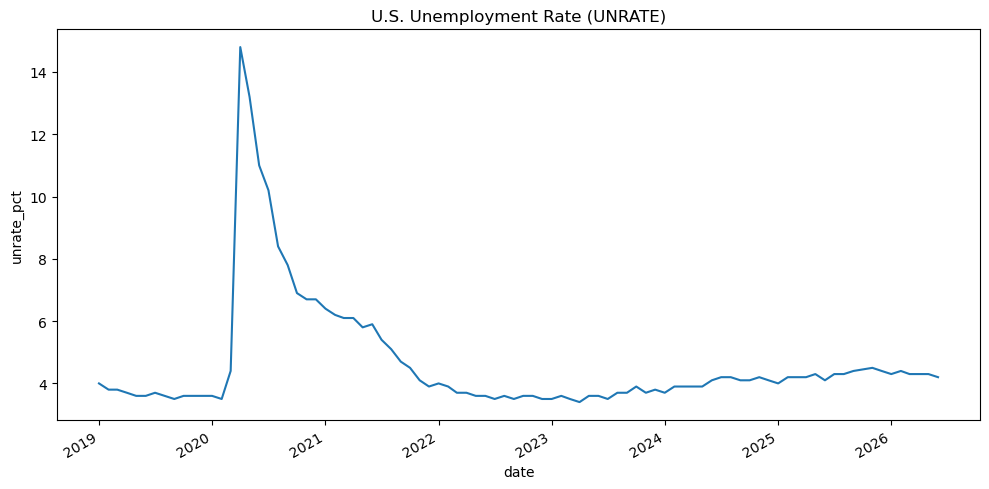

In [16]:
unrate_plot_df = saved_unrate_df.dropna(
    subset=["date", "unrate_pct"]
).set_index("date")

ax = unrate_plot_df["unrate_pct"].plot(
    kind="line",
    figsize=(10,5),
)
ax.set_title("U.S. Unemployment Rate (UNRATE)")
ax.set_xlabel("date")
ax.set_ylabel("unrate_pct")

plt.tight_layout()
plt.show()

In [19]:
analysis_df = saved_unrate_df.dropna(
    subset=["date", "unrate_pct"]
).sort_values("date").copy()

if analysis_df.empty:
    raise ValueError("해석할 수 있는 UNRATE 관측값이 없습니다.")

start_row = analysis_df.iloc[0]
end_row = analysis_df.iloc[-1]
peak_row = analysis_df.loc[analysis_df["unrate_pct"].idxmax()]

start_date = start_row["date"]
end_date = end_row["date"]
peak_date = peak_row["date"]

start_value = float(start_row["unrate_pct"])
end_value = float(end_row["unrate_pct"])
peak_value = float(peak_row["unrate_pct"])
change_value = end_value - start_value

if change_value > 0:
    direction_text = f"{abs(change_value):.1f}퍼센트포인트 증가했다"
elif change_value < 0:
    direction_text = f"{abs(change_value):.1f}퍼센트포인트 감소했다"
else:
    direction_text = "같았다"

interpretation_sentence = (
    f"{start_date:%Y-%m}부터 {end_date:%Y-%m}까지 UNRATE는 "
    f"{start_value:.1f}%에서 {end_value:.1f}%로 {direction_text}. "
    f"기간 중 가장 높은 값은 {peak_date:%Y-%m}의 {peak_value:.1f}%였다. "
    "이 값은 U.S. Bureau of Labor Statistics가 제공하는 월별 계절조정 실업률을 "
    "FRED에서 받은 것이며, 이 그래프만으로 변화 원인을 단정하지 않는다."
)

print("start_value:", start_value)
print("end_value:", end_value)
print("change_value:", change_value)
print("peak_date:", peak_date.date())
print("peak_value:", peak_value)
print(interpretation_sentence)
analysis_df = saved_unrate_df.dropna(
    subset=["date", "unrate_pct"]
).sort_values("date").copy()

if analysis_df.empty:
    raise ValueError("해석할 수 있는 UNRATE 관측값이 없습니다.")

start_row = analysis_df.iloc[0]
end_row = analysis_df.iloc[-1]
peak_row = analysis_df.loc[analysis_df["unrate_pct"].idxmax()]

start_date = start_row["date"]
end_date = end_row["date"]
peak_date = peak_row["date"]

start_value = float(start_row["unrate_pct"])
end_value = float(end_row["unrate_pct"])
peak_value = float(peak_row["unrate_pct"])
change_value = end_value - start_value

if change_value > 0:
    direction_text = f"{abs(change_value):.1f}퍼센트포인트 증가했다"
elif change_value < 0:
    direction_text = f"{abs(change_value):.1f}퍼센트포인트 감소했다"
else:
    direction_text = "같았다"

interpretation_sentence = (
    f"{start_date:%Y-%m}부터 {end_date:%Y-%m}까지 UNRATE는 "
    f"{start_value:.1f}%에서 {end_value:.1f}%로 {direction_text}. "
    f"기간 중 가장 높은 값은 {peak_date:%Y-%m}의 {peak_value:.1f}%였다. "
    "이 값은 U.S. Bureau of Labor Statistics가 제공하는 월별 계절조정 실업률을 "
    "FRED에서 받은 것이며, 이 그래프만으로 변화 원인을 단정하지 않는다."
)

print("start_value:", start_value)
print("end_value:", end_value)
print("change_value:", change_value)
print("peak_date:", peak_date.date())
print("peak_value:", peak_value)
print(interpretation_sentence)

start_value: 4.0
end_value: 4.2
change_value: 0.20000000000000018
peak_date: 2020-04-01
peak_value: 14.8
2019-01부터 2026-06까지 UNRATE는 4.0%에서 4.2%로 0.2퍼센트포인트 증가했다. 기간 중 가장 높은 값은 2020-04의 14.8%였다. 이 값은 U.S. Bureau of Labor Statistics가 제공하는 월별 계절조정 실업률을 FRED에서 받은 것이며, 이 그래프만으로 변화 원인을 단정하지 않는다.
start_value: 4.0
end_value: 4.2
change_value: 0.20000000000000018
peak_date: 2020-04-01
peak_value: 14.8
2019-01부터 2026-06까지 UNRATE는 4.0%에서 4.2%로 0.2퍼센트포인트 증가했다. 기간 중 가장 높은 값은 2020-04의 14.8%였다. 이 값은 U.S. Bureau of Labor Statistics가 제공하는 월별 계절조정 실업률을 FRED에서 받은 것이며, 이 그래프만으로 변화 원인을 단정하지 않는다.
